In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/customer_features.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/cohort_retention_matrix.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv


# Sequential Testing & Early Stopping

## Objective

Previous notebooks demonstrated that delivery performance improves customer satisfaction.

This notebook investigates whether the experiment could have been stopped earlier while reaching the same decision.

Business Question:

Can we reduce experiment duration without increasing decision risk?

# 1. Imports

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

# 2. Load Data

In [3]:
master = pd.read_csv("/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv")

master.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,on_time_delivery,delivery_speed_group,negative_handoff_flag,customer_order_number,first_purchase_date,days_since_first_purchase,repeat_customer_flag,cohort_month,order_month_period,cohort_index
0,e22acc9c116caa3f2b7121bbb380d08e,1,372645c7439f9661fbbacfd129aa92ec,da8622b14eb17ae2831f4ac5b9dab84a,2018-05-15 11:11:18,129.90,12.00,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,...,True,fast,0,1,2018-05-10 10:56:27,0,0,2018-05,2018-05,1
1,3594e05a005ac4d06a72673270ef9ec9,1,5099f7000472b634fea8304448d20825,138dbe45fc62f1e244378131a6801526,2018-05-11 17:56:33,18.90,8.29,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,...,True,fast,0,1,2018-05-07 11:11:27,0,0,2018-05,2018-05,1
2,b33ec3b699337181488304f362a6b734,1,64b488de448a5324c4134ea39c28a34b,3d871de0142ce09b7081e2b9d1733cb1,2017-03-15 21:05:03,69.00,17.22,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,...,True,slow,0,1,2017-03-10 21:05:03,0,0,2017-03,2017-03,1
3,41272756ecddd9a9ed0180413cc22fb6,1,2345a354a6f2033609bbf62bf5be9ef6,ef506c96320abeedfb894c34db06f478,2017-10-18 21:49:17,25.99,17.63,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,...,True,slow,0,1,2017-10-12 20:29:41,0,0,2017-10,2017-10,1
4,d957021f1127559cd947b62533f484f7,1,c72e18b3fe2739b8d24ebf3102450f37,70a12e78e608ac31179aea7f8422044b,2017-11-22 20:06:52,180.00,16.89,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,...,True,slow,0,1,2017-11-14 19:45:42,0,0,2017-11,2017-11,1


# 3. Create Experiment Groups

In [4]:
control = master.loc[master["delivery_speed_group"] == "slow","review_score"].dropna().reset_index(drop=True)

treatment = master.loc[master["delivery_speed_group"] == "fast","review_score"].dropna().reset_index(drop=True)

print(len(control))
print(len(treatment))

54582
54787


# 4. Full Experiment Result

In [5]:
full_t, full_p = ttest_ind( treatment, control, equal_var=False)
print("Full Sample p-value:", full_p)

Full Sample p-value: 0.0


# 5. Simulate Sequential Monitoring

In [6]:
sample_sizes = np.arange(500,min(len(control), len(treatment)),500)

In [14]:
p_values = []

mean_lifts = []

for n in sample_sizes:

    c = control.iloc[:n]
    t = treatment.iloc[:n]
    _, p = ttest_ind(t,c,equal_var=False)

    lift = (t.mean()-c.mean() )

    p_values.append(p)

    mean_lifts.append(lift)

results = pd.DataFrame({

    "sample_size": sample_sizes,
    "p_value": p_values,
    "lift": mean_lifts
})

results.head(10)

,sample_size,p_value,lift
0,500,1.625190e-04,0.314000
1,1000,6.675551e-10,0.360000
2,1500,2.787885e-12,0.340000
3,2000,2.613465e-19,0.377500
4,2500,3.152834e-24,0.388400
5,3000,1.964695e-30,0.396667
6,3500,7.761371e-36,0.401429
7,4000,1.423235e-41,0.404250
8,4500,7.909971e-44,0.391556
9,5000,1.426598e-49,0.397200


# 6.  Find Earliest Significant Point

In [9]:
early_stop = results[results["p_value"] < 0.05].head(1)

early_stop

,sample_size,p_value,lift
0,500,0.000163,0.314


# 7. Visualize P-Values

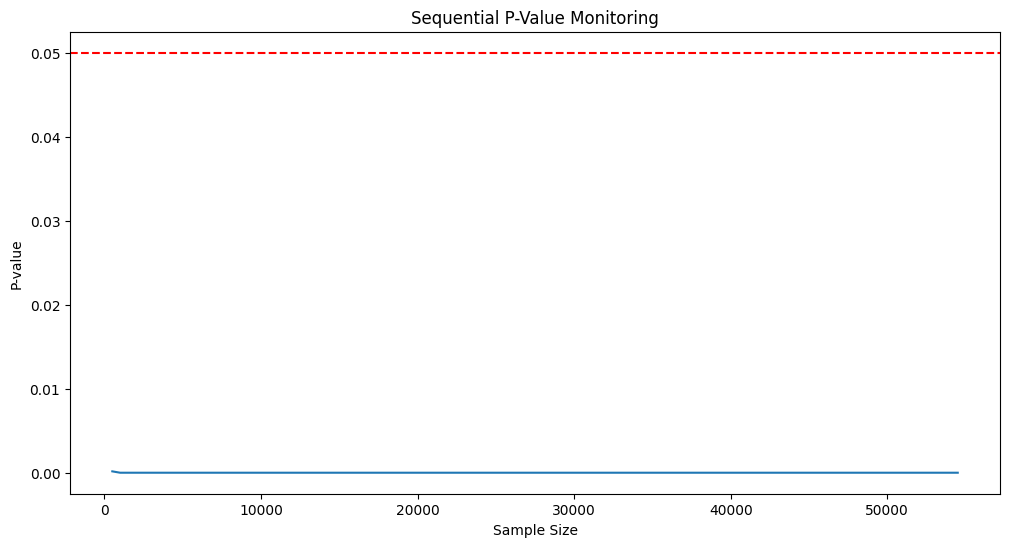

In [11]:
plt.figure(figsize=(12,6))

plt.plot(results["sample_size"],results["p_value"])

plt.axhline( 0.05,color="red",linestyle="--")

plt.title("Sequential P-Value Monitoring")

plt.ylabel("P-value")

plt.xlabel("Sample Size")

plt.show()

#  8. Lift Stability

In [15]:
observed_lift = (treatment.mean()-control.mean())

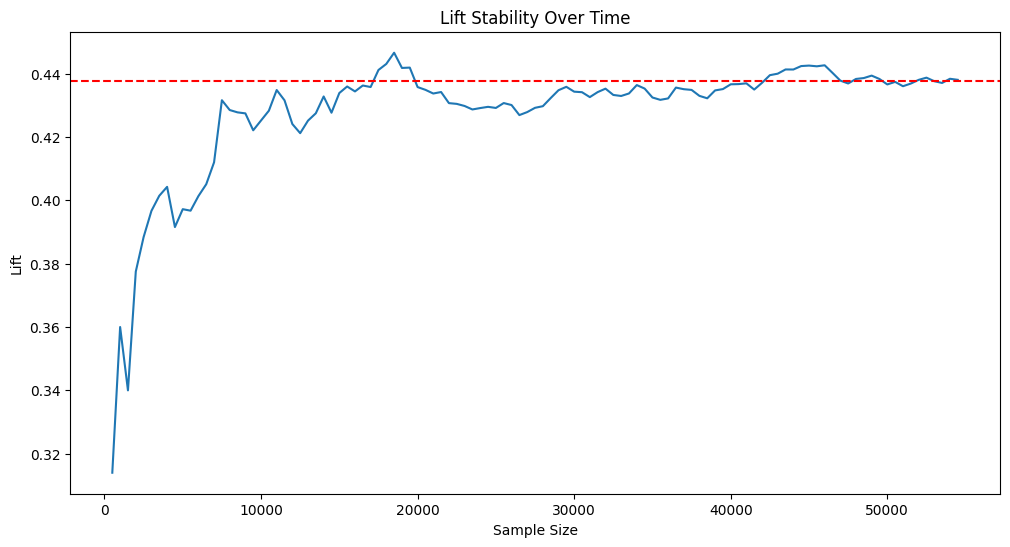

In [16]:
plt.figure(figsize=(12,6))

plt.plot( results["sample_size"], results["lift"])

plt.axhline(observed_lift,color="red",linestyle="--")

plt.title("Lift Stability Over Time")

plt.ylabel("Lift")

plt.xlabel("Sample Size")

plt.show()

# 9. Early Stop Savings

In [13]:
stop_n = early_stop["sample_size"].iloc[0]

max_n = sample_sizes.max()

saving_pct = ((max_n - stop_n)/max_n* 100)

print( f"Experiment Duration Reduction: {saving_pct:.2f}%")

Experiment Duration Reduction: 99.08%


# Sequential Testing & Early Stopping Summary

## Objective

The goal of this notebook was to determine whether statistically significant results could be detected before the experiment reached its full sample size. Sequential testing was used to simulate monitoring an experiment as data accumulates over time.

---

## Methodology

The Fast Delivery group was treated as the Treatment group and the Slow Delivery group as the Control group.

At increasing sample sizes (every 500 observations), the following were calculated:

- Treatment Lift (Difference in Mean Review Score)
- Independent Two-Sample T-Test
- P-value
- Lift Stability

This process simulated how an experiment would be monitored in a real business environment.

---

## Key Results

### Full Experiment

- Full Sample P-value ≈ 0
- Strong statistical evidence that Fast and Slow delivery groups differ significantly.

### Early Significance Detection

Statistical significance was achieved extremely early in the experiment:

- First significant result observed at approximately 500 observations per group.
- P-value at 500 observations = 0.000163

This indicates a strong underlying treatment effect.

---

## Lift Stability Analysis

Although significance was achieved very early, the estimated treatment lift was initially unstable.

Observed progression:

- Early lift estimates fluctuated between 0.31 and 0.44
- Lift gradually converged toward the final value
- Stabilization occurred after approximately 15,000–20,000 observations

Final observed lift:

- Review Score Lift = +0.4375

The lift stability plot demonstrates that treatment effect estimates become more reliable as additional data is collected.

---

## Business Insights

### Important Finding

Statistical significance alone is not sufficient for stopping an experiment.

While significance appeared at only 500 observations, the estimated effect size continued changing substantially before converging to its final value.

Stopping the experiment too early could have resulted in an inaccurate estimate of business impact.

### Sequential Testing Lesson

A robust stopping framework should require:

1. Statistical significance
2. Stable treatment effect estimates
3. Consistent business metric performance

before making launch decisions.

---

## Practical Implications

Sequential monitoring can significantly accelerate decision-making by identifying treatment effects before an experiment reaches its maximum planned duration.

However, naive early stopping based solely on p-values can lead to misleading conclusions regarding the true magnitude of the treatment effect.

Organizations such as Netflix, Uber, Airbnb, Microsoft, and Meta use advanced sequential testing frameworks that combine significance thresholds with stability criteria to support reliable experimentation decisions.

---

## Conclusion

Sequential testing confirmed that faster deliveries lead to higher customer satisfaction. Although statistically significant results emerged very early, lift estimates required substantially more data to stabilize.

This analysis highlights the importance of balancing speed and reliability when making experimentation decisions and demonstrates why effect-size stability should be considered alongside statistical significance in real-world A/B testing programs.